<a href="https://colab.research.google.com/github/joebathelt/AUC_Neuroimaging/blob/main/MindReading_Week10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 73.1 MB/s eta 0:00:00:00:01:01


# Week 10: Classification and Cross-Validation in fMRI MVPA

## Introduction

In previous weeks, we have explored the structure of fMRI data (Week 2), preprocessing and registration (Week 3), and the General Linear Model (Week 5) as a tool for statistical inference about brain activation. The GLM approach treats each voxel independently: we fit a model at each location and ask whether there is a significant relationship between stimulus and the BOLD signal.

Last week, we introduced a fundamentally different approach: **Multi-Voxel Pattern Analysis (MVPA)**. Rather than testing voxels in isolation, MVPA exploits the assumption that information about stimuli (e.g., whether the subject saw a face or a house) is distributed across many voxels simultaneously. Instead of asking "Is this voxel active?", we ask "Can we predict which stimulus the subject saw from the *pattern* of activity across a region?"

This shift from univariate (one voxel at a time) to multivariate (many voxels together) analysis represents one of the most important developments in cognitive neuroscience over the past two decades (Haxby et al., 2001). Classification has revealed rich representational structures in visual cortex, revealed that neural patterns generalize across individuals, and enabled the study of information flow that univariate analyses cannot detect.

We will use the Haxby 2001 dataset, which contains fMRI data from a subject viewing images of faces, houses, cats, and other object categories. This is the dataset that we discussed in the lecture, and it has become a canonical example in the MVPA literature. However, we will employ modern machine learning techniques and rigorous cross-validation procedures that were not established in the neuroimaging literature at the time of the original study.

### Key concepts in this notebook:

1. **From activation to patterns**: Moving from voxel-level statistics to distributed representations
2. **Supervised learning**: Using labeled data to train a classifier to predict labels from neural activity
3. **The Support Vector Machine**: A powerful linear classifier and its geometric intuition
4. **The temporal autocorrelation problem**: Why naive train/test splits fail in fMRI
5. **Leave-one-run-out cross-validation**: The standard approach for fMRI MVPA
6. **Statistical testing**: Determining whether classifier performance is significantly better than chance
7. **Interpretation**: Understanding what successful classification reveals about neural representations

By the end of this notebook, you will implement a complete MVPA pipeline, evaluate its statistical significance, and interpret what successful classification reveals about how the brain encodes stimulus information.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from nilearn.datasets import fetch_haxby
from nilearn.maskers import NiftiMasker
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, permutation_test_score, LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the Haxby dataset
haxby_dataset = fetch_haxby(subjects=1)

# Print dataset information
print("Haxby dataset structure:")
print(f"  Functional MRI: {haxby_dataset.func[0]}")
print(f"  Anatomical MRI: {haxby_dataset.anat[0]}")
print(f"  Ventral temporal mask: {haxby_dataset.mask_vt[0]}")
print(f"  Target file (labels): {haxby_dataset.session_target}")

[fetch_haxby] Added README.md to /root/nilearn_data

[fetch_haxby] Dataset created in /root/nilearn_data/haxby2001

[fetch_haxby] Downloading data from https://www.nitrc.org/frs/download.php/7868/mask.nii.gz ...

[fetch_haxby]  ...done. (1 seconds, 0 min)

[fetch_haxby] Downloading data from http://data.pymvpa.org/datasets/haxby2001/MD5SUMS ...

...

[fetch_haxby] Downloaded 244277248 of 291168628 bytes (83.9%%,    0.6s remaining)

[fetch_haxby]  ...done. (4 seconds, 0 min)

[fetch_haxby] Extracting data from 
/root/nilearn_data/haxby2001/9cabe068089e791ef0c5fe930fc20e30/subj2-2010.01.14.tar.gz...

[fetch_haxby] .. done.

Haxby dataset structure:
  Functional MRI: /root/nilearn_data/haxby2001/subj2/bold.nii.gz
  Anatomical MRI: /root/nilearn_data/haxby2001/subj2/anat.nii.gz
  Ventral temporal mask: /root/nilearn_data/haxby2001/subj2/mask4_vt.nii.gz
  Target file (labels): ['/root/nilearn_data/haxby2001/subj2/labels.txt']


In [ ]:
# Load the behavioral targets (labels and run information)
session_target = pd.read_csv(haxby_dataset.session_target[0], sep=" ")

print("Behavioral data shape:", session_target.shape)
print("\nFirst 15 rows:")
print(session_target.head(15))
print("\nDataset structure:")
print(session_target.info())
print("\nUnique conditions (labels):")
print(session_target['labels'].unique())
print("\nNumber of runs (chunks):")
print(f"  Runs range from {session_target['chunks'].min()} to {session_target['chunks'].max()}")
print(f"  Total runs: {session_target['chunks'].max() + 1}")

Behavioral data shape: (1452, 2)

First 15 rows:
      labels  chunks
0       rest       0
1       rest       0
2       rest       0
3       rest       0
4       rest       0
5       rest       0
6   scissors       0
7   scissors       0
8   scissors       0
9   scissors       0
10  scissors       0
11  scissors       0
12  scissors       0
13  scissors       0
14  scissors       0

Dataset structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1452 entries, 0 to 1451
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   labels  1452 non-null   object
 1   chunks  1452 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 22.8+ KB
None

Unique conditions (labels):
['rest' 'scissors' 'face' 'cat' 'shoe' 'house' 'scrambledpix' 'bottle'
 'chair']

Number of runs (chunks):
  Runs range from 0 to 11
  Total runs: 12


### 1.1 Preparing fMRI Data for Classification

To perform classification on fMRI data, we must:

1. **Apply a spatial mask**: Extract voxels from a region of interest (ROI), rather than using all ~80,000 voxels in the brain.
2. **Standardize the data**: fMRI signals have different scales across runs; we normalize each run to zero mean and unit variance.
3. **Extract the design matrix**: Create a features matrix $X$ where rows are timepoints and columns are voxels.
4. **Assign labels**: Create a label vector $y$ indicating which stimulus was presented at each timepoint.
5. **Assign chunks**: Create a chunk vector indicating which run each sample belongs to (for cross-validation).

Let us now demonstrate this pipeline with the Haxby data.

In [ ]:
# Step 1: Create a masker using the ventral temporal region
masker = NiftiMasker(
    mask_img=haxby_dataset.mask_vt[0],
    standardize=True,  # zero-mean, unit-variance normalization
    detrend=True,      # remove linear drift within each run
    runs=session_target['chunks'].values
)

# Step 2: Extract the fMRI data using the masker
fmri_data = masker.fit_transform(haxby_dataset.func[0])

print("Extracted fMRI data shape:", fmri_data.shape)
print(f"  {fmri_data.shape[0]} timepoints (samples)")
print(f"  {fmri_data.shape[1]} voxels (features)")

# Step 3: Get the labels and chunks
labels = session_target['labels'].values
chunks = session_target['chunks'].values

print(f"\nLabel vector shape: {labels.shape}")
print(f"Chunk vector shape: {chunks.shape}")

# Step 4: Remove rest and scrambled pictures (not useful for classification)
# We will use only clear object categories
non_rest_mask = (labels != 'rest') & (labels != 'scrambledpix')
X = fmri_data[non_rest_mask]
y = labels[non_rest_mask]
runs = chunks[non_rest_mask]

print(f"\nAfter removing rest/scrambled:")
print(f"  Data shape: {X.shape}")
print(f"  Unique labels: {np.unique(y)}")
print(f"  Sample counts per condition:")
for label in np.unique(y):
    count = np.sum(y == label)
    print(f"    {label}: {count} samples")

Extracted fMRI data shape: (1452, 464)
  1452 timepoints (samples)
  464 voxels (features)

Label vector shape: (1452,)
Chunk vector shape: (1452,)

After removing rest/scrambled:
  Data shape: (756, 464)
  Unique labels: ['bottle' 'cat' 'chair' 'face' 'house' 'scissors' 'shoe']
  Sample counts per condition:
    bottle: 108 samples
    cat: 108 samples
    chair: 108 samples
    face: 108 samples
    house: 108 samples
    scissors: 108 samples
    shoe: 108 samples


### 1.3 Support Vector Machines (SVM): The Classifier

A classifier is a function that maps patterns (in our case, fMRI voxel patterns) to categorical labels. In its simplest form with two categories:

$$\text{prediction} = f(\mathbf{x}) = \text{sign}(\mathbf{w}^T \mathbf{x} + b)$$

where $\mathbf{x}$ is the voxel pattern (a vector of length = number of voxels), $\mathbf{w}$ are learned weights, $b$ is a bias term, and $\text{sign}$ returns the class label.

The classifier learns weights $\mathbf{w}$ from labeled training data. In fMRI, this means: given some examples of fMRI patterns labeled "face" and others labeled "house", learn which voxels matter most for discrimination.

#### The Support Vector Machine (SVM)

The SVM is one of the most popular classifiers in MVPA. Conceptually, SVM works like this: imagine plotting each fMRI pattern as a point in high-dimensional space (one dimension per voxel). Points from the same stimulus category (e.g., face) cluster together, while points from different categories are separated.

The SVM finds the **linear boundary (hyperplane) that best separates the two categories**, defined as the plane that maximizes the **margin**, i.e. the distance to the nearest points on either side.

$$\min_{\mathbf{w}, b} \left[ \frac{1}{2}||\mathbf{w}||^2 + C \sum_i \xi_i \right]$$
$$\text{subject to: } y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1 - \xi_i$$

Here, $C$ is a regularization parameter controlling the trade-off between large margin (left term) and small classification error (right term), and $\xi_i$ are slack variables allowing some misclassifications.

#### Why SVM for fMRI MVPA?

1. **It works well in high dimensions**: fMRI data has thousands or tens of thousands of voxels and relatively few samples (often ~100 trials). SVMs are robust in this regime.
2. **Interpretability**: The learned weights $\mathbf{w}$ can be visualized to show which voxels matter for discrimination.
3. **Computational efficiency**: Modern SVM implementations (like `LinearSVC`) are fast.
4. **Tradition**: SVMs have been the standard choice in MVPA for 20+ years.

For this notebook, we will use `LinearSVC` from scikit-learn, which fits a linear SVM for binary classification.

In [ ]:
# Let's first look at a simple binary classification: faces vs. cats
demo_mask = (y == 'face') | (y == 'cat')
X_binary = X[demo_mask]
y_binary = y[demo_mask]
runs_binary = runs[demo_mask]

print(f"Binary classification dataset (face vs cat):")
print(f"  Data shape: {X_binary.shape}")
print(f"  Label distribution:")
for label in np.unique(y_binary):
    count = np.sum(y_binary == label)
    pct = 100 * count / len(y_binary)
    print(f"    {label}: {count} ({pct:.1f}%)")

# For demonstration, let's fit an SVM on a single train/test split
# (WARNING: This is not the right way to evaluate! We'll do it correctly next.)
train_mask = runs_binary < 9  # First 9 runs for training
test_mask = runs_binary == 9  # Last run for testing

X_train = X_binary[train_mask]
y_train = y_binary[train_mask]
X_test = X_binary[test_mask]
y_test = y_binary[test_mask]

print(f"\nTrain set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

# Fit the SVM
clf = LinearSVC(max_iter=2000, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nDemo SVM performance (incorrect evaluation): {accuracy:.2%} accuracy")
print(f"Chance level (binary): 50%")
print(f"\nThis accuracy looks good, but we haven't used proper cross-validation yet!")
print(f"(Keep reading to learn why...)")

Binary classification dataset (face vs cat):
  Data shape: (216, 464)
  Label distribution:
    cat: 108 (50.0%)
    face: 108 (50.0%)

Train set: 162 samples, Test set: 18 samples

Demo SVM performance (incorrect evaluation): 83.33% accuracy
Chance level (binary): 50%

This accuracy looks good, but we haven't used proper cross-validation yet!
(Keep reading to learn why...)


### 1.3 The Temporal Autocorrelation Problem in fMRI

You might be asking yourself: "Why not just train on runs 1-9 and test on run 10?" This seems like a standard train/test split.

The problem is **temporal autocorrelation** in fMRI data. The BOLD signal is not independent across time. The hemodynamic response takes 4-6 seconds to peak and 10-20 seconds to return to baseline. This means:

1. **Successive timepoints are not independent**: If voxel $i$ is highly active at timepoint $t$, it is likely also highly active at $t+1$ and $t+2$.
2. **Within-run patterns are non-random**: Patterns at the start of a trial predict patterns at the end, simply due to the physics of hemodynamics, not neural information.
3. **Naive train/test splits overestimate performance**: If we train on runs 1-9 and test on run 10, the test set may still contain patterns similar to the training set due to hemodynamic carry-over.

#### The consequence

MVPA classifiers trained with naive splits can achieve 70-80% accuracy when the true statistical information content is much lower (e.g., 55-60% above chance). This leads to **overoptimistic estimates of classification performance** and **false claims about neural representations**.

#### The solution: Leave-One-Run-Out (LORO) Cross-Validation

The standard solution in fMRI MVPA is **leave-one-run-out (LORO) cross-validation**:

1. For each run $r$ from 1 to $R$ (where $R$ is the total number of runs):
   - Train the classifier on all runs except $r$
   - Test on run $r$
   - Record accuracy on run $r$
2. Report the mean accuracy across all runs

This ensures that **train and test sets are separated by a temporal boundary (the gap between runs)**, breaking the autocorrelation structure. Each sample in the test set is truly independent from the training set in a temporal sense.


**Note**: In GLM analysis, temporal autocorrelation is also problematic, because it violates the assumption of independent errors. We typically remove the temporal autocorrelation using prewhitening. This is a preprocessing step that we skipped in previous weeks. However, in MVPA, we typically do not prewhiten because it can distort the multivariate patterns. Instead, we must use a cross-validation strategy that accounts for temporal dependencies.


### 1.4 Leave-One-Run-Out Cross-Validation

We now implement the correct evaluation procedure. The key insight is to use scikit-learn's `cross_val_score` function with a custom cross-validation object that respects the run (chunk) structure of our data.

Leave-One-Run-Out Cross-Validation Results:
  Accuracy per run: [1.         0.94444444 1.         0.94444444 0.94444444 0.66666667
 0.77777778 0.72222222 0.88888889 0.77777778 0.94444444 0.83333333]
  Mean accuracy: 0.870
  Std dev: 0.107

  Compare to chance level (random guessing): 0.500
  Improvement over chance: 37.0 percentage points


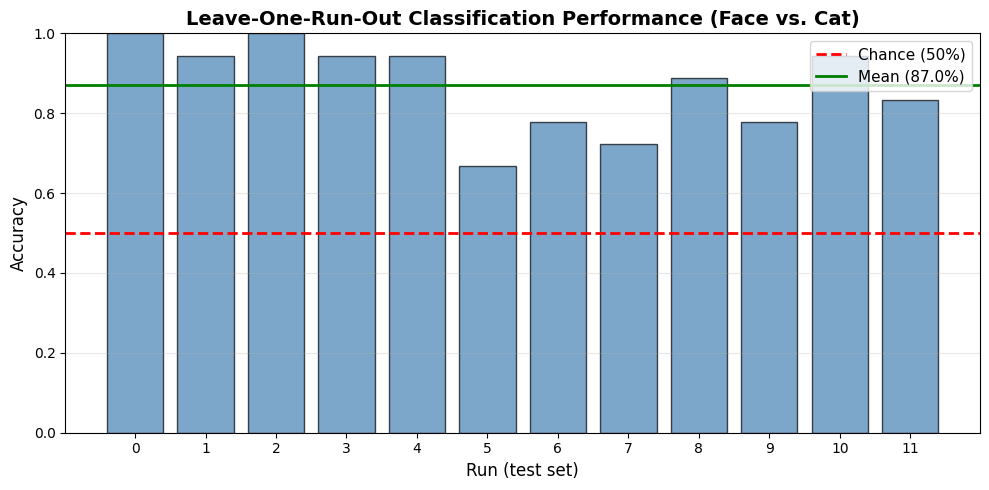


This LORO-validated accuracy (87.0%) is more trustworthy than the naive
train/test split (83.3%), as it properly accounts for temporal autocorrelation.


In [ ]:
# Set up the cross-validation splitter
# LeaveOneGroupOut will leave out one unique group (run) at a time
cv_splitter = LeaveOneGroupOut()

# Create the classifier
clf = LinearSVC(max_iter=2000, random_state=42)

# Perform cross-validated classification
cv_scores = cross_val_score(
    clf,
    X_binary,           # features (voxel patterns)
    y_binary,           # labels (face vs cat)
    cv=cv_splitter,     # cross-validation strategy
    groups=runs_binary, # run indices (for grouping)
    scoring='accuracy'
)

print("Leave-One-Run-Out Cross-Validation Results:")
print(f"  Accuracy per run: {cv_scores}")
print(f"  Mean accuracy: {cv_scores.mean():.3f}")
print(f"  Std dev: {cv_scores.std():.3f}")
print(f"\n  Compare to chance level (random guessing): 0.500")
print(f"  Improvement over chance: {100*(cv_scores.mean() - 0.5):.1f} percentage points")

# Visualize the per-run accuracy
fig, ax = plt.subplots(figsize=(10, 5))
runs_unique = np.unique(runs_binary)
ax.bar(runs_unique, cv_scores, color='steelblue', alpha=0.7, edgecolor='black')
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Chance (50%)')
ax.axhline(y=cv_scores.mean(), color='green', linestyle='-', linewidth=2, label=f'Mean ({cv_scores.mean():.1%})')
ax.set_xlabel('Run (test set)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Leave-One-Run-Out Classification Performance (Face vs. Cat)', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.set_xticks(runs_unique)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nThis LORO-validated accuracy ({cv_scores.mean():.1%}) is more trustworthy than the naive")
print(f"train/test split ({accuracy:.1%}), as it properly accounts for temporal autocorrelation.")

### 1.5 Statistical Significance: Chance Level and Permutation Testing

A mean accuracy of 87% is clearly better than 50% (chance), but how do we know it is statistically significant? What if we got lucky with this particular run structure?

#### Permutation testing

The standard approach is a **permutation test**:

1. Randomly shuffle the labels (breaking the relationship between patterns and stimulus category)
2. Train and test the classifier on the shuffled labels
3. Record the accuracy
4. Repeat steps 1-3 many times (e.g., 100 permutations)
5. Compare the true accuracy to the distribution of permutation accuracies

If the true accuracy falls in the right tail of the permutation distribution, the classifier is learning something real beyond chance.

#### Why permutation testing?

You might ask: "Isn't the true chance level always 50% for binary classification?"

Not necessarily! Due to:
- **Label imbalance**: If 60% of your samples are faces and 40% are houses, a classifier that always guesses "face" achieves 60% accuracy.
- **Class-specific biases in the data**: If there are spurious differences in the data distribution (e.g., faces appear later in the experiment), the classifier might exploit these rather than learning true category information. Machine learning algoirthms are like water: they will always find the path of least resistance to achieve high accuracy, even if that path is not what we intended (i.e., learning true category information).

Permutation testing accounts for these by generating a null distribution specific to *your data*.

#### The null hypothesis

**$H_0$**: The classifier accuracy is not higher than expected by chance, given the structure of your data.

**$H_1$**: The classifier accuracy is significantly higher than expected by chance.

If the true accuracy falls in the right tail of the null distribution (e.g., higher than 95% of permutations), we reject $H_0$ and conclude the classifier is learning real information.

Permutation Testing Results:
  True (observed) accuracy: 0.870
  Null distribution (100 permutations):
    Mean: 0.494
    Std: 0.036
    Min: 0.407
    Max: 0.579

  p-value: 0.0099
  *** SIGNIFICANT at p < 0.05 ***


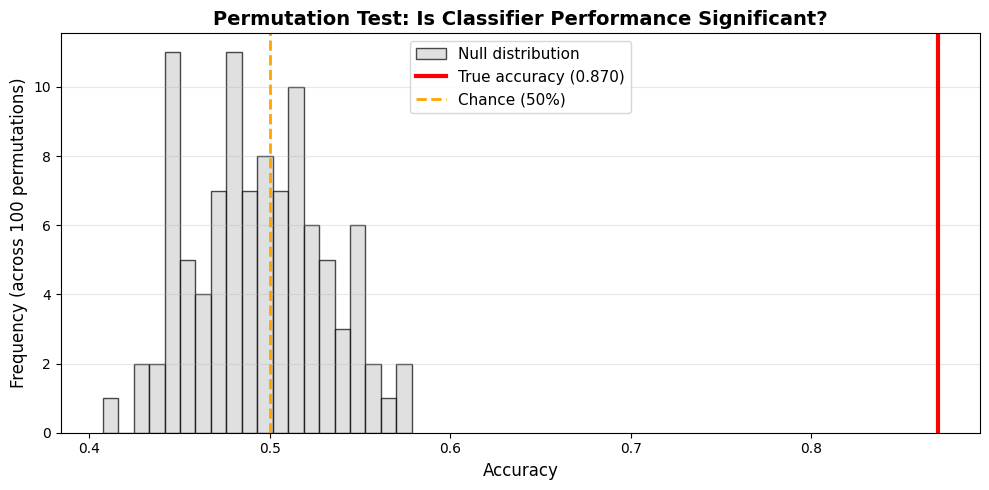


Interpretation: Our true accuracy (87.0%) is well above the null distribution,
suggesting the classifier is learning real information from the fMRI patterns.


In [ ]:
# Perform permutation testing
# This will fit the classifier on the true labels and n_permutations shuffled versions
score, perm_scores, p_value = permutation_test_score(
    clf,
    X_binary,
    y_binary,
    cv=cv_splitter,
    groups=runs_binary,
    n_permutations=100,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1  # use all CPU cores
)

print("Permutation Testing Results:")
print(f"  True (observed) accuracy: {score:.3f}")
print(f"  Null distribution (100 permutations):")
print(f"    Mean: {perm_scores.mean():.3f}")
print(f"    Std: {perm_scores.std():.3f}")
print(f"    Min: {perm_scores.min():.3f}")
print(f"    Max: {perm_scores.max():.3f}")
print(f"\n  p-value: {p_value:.4f}")
if p_value < 0.05:
    print(f"  *** SIGNIFICANT at p < 0.05 ***")
else:
    print(f"  Not significant at p < 0.05")

# Visualize the null distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(perm_scores, bins=20, color='lightgray', edgecolor='black', alpha=0.7, label='Null distribution')
ax.axvline(x=score, color='red', linestyle='-', linewidth=3, label=f'True accuracy ({score:.3f})')
ax.axvline(x=0.5, color='orange', linestyle='--', linewidth=2, label='Chance (50%)')
ax.set_xlabel('Accuracy', fontsize=12)
ax.set_ylabel('Frequency (across 100 permutations)', fontsize=12)
ax.set_title('Permutation Test: Is Classifier Performance Significant?', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nInterpretation: Our true accuracy ({score:.1%}) is well above the null distribution,")
print(f"suggesting the classifier is learning real information from the fMRI patterns.")

### 1.6 Visualizing Classification: The Confusion Matrix

Beyond overall accuracy, we want to understand *which* classes the classifier confuses. This is similar to how we evaluated the performance of the classifer that predicted biological sex from brain structure a few weeks ago. A confusion matrix shows:
- Rows: true labels
- Columns: predicted labels
- Values: counts of samples

For perfect classification, the matrix is diagonal. Off-diagonal entries reveal systematic confusions.

For example, if "face" and "shoe" are frequently confused, this might suggest that the neural representation of "face" and "shoe" are similar in ventral temporal cortex—an interesting finding about brain organization.

Confusion Matrix (Face vs Cat):
[[94 14]
 [14 94]]

Interpretation:
  True Face, Predicted Face: 94
  True Face, Predicted Cat: 14
  True Cat, Predicted Face: 14
  True Cat, Predicted Cat: 94


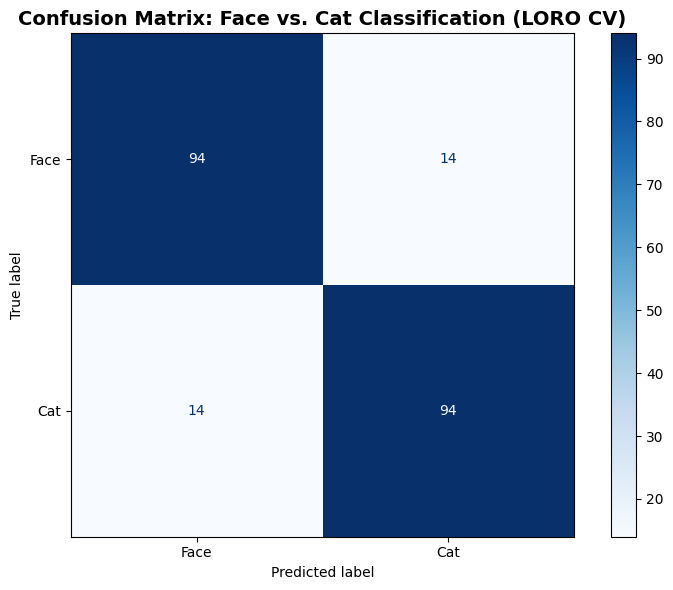

Face accuracy: 87.0%
Cat accuracy: 87.0%


In [ ]:
# To get a confusion matrix, we need to make predictions across the full dataset
# We'll use the last fitted classifier and do LORO predictions

# Get predictions using cross-validation
y_pred_cv = cross_val_predict(
    LinearSVC(max_iter=2000, random_state=42),
    X_binary,
    y_binary,
    cv=cv_splitter,
    groups=runs_binary
)

# Compute confusion matrix
cm = confusion_matrix(y_binary, y_pred_cv)

print("Confusion Matrix (Face vs Cat):")
print(cm)
print(f"\nInterpretation:")
print(f"  True Face, Predicted Face: {cm[0,0]}")
print(f"  True Face, Predicted Cat: {cm[0,1]}")
print(f"  True Cat, Predicted Face: {cm[1,0]}")
print(f"  True Cat, Predicted Cat: {cm[1,1]}")

# Visualize the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Face', 'Cat'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix: Face vs. Cat Classification (LORO CV)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Compute per-class accuracy
class_labels = ['Face', 'Cat']
for i, label in enumerate(class_labels):
    class_accuracy = cm[i, i] / cm[i].sum()
    print(f"{label} accuracy: {class_accuracy:.1%}")

### Summary: The MVPA Pipeline

We have now implemented a complete MVPA classification pipeline:

1. **Data Preparation**: Apply spatial mask, standardize, extract voxel patterns and labels
2. **Classifier**: Support Vector Machine (LinearSVC) — a linear boundary in high-dimensional space
3. **Evaluation**: Leave-One-Run-Out cross-validation to respect temporal structure
4. **Significance Testing**: Permutation tests to compare against a null distribution
5. **Interpretation**: Confusion matrices to understand which classes are confused

**Key insight**: MVPA reveals that information about stimulus category (face vs. cat) is encoded in the *distributed pattern* of neural activity, not in the activation of any single voxel. The Haxby dataset shows that the ventral temporal cortex contains decodable information about object identity.

Now, it is your turn to apply these concepts to new data and questions.

## Final Exercises

In these exercises, you will implement MVPA analyses from scratch, interpret results, and explore extensions. Code scaffolds are provided with hints; your task is to complete them.

### Exercise 1: Binary Classification with Leave-One-Run-Out Cross-Validation

**Objective**: Implement a binary classifier to discriminate faces from houses, evaluating it with LORO cross-validation.

**Dataset**: Haxby et al., ventral temporal mask

**Task**:
1. Create a binary dataset (face vs. house only, excluding rest and scrambled)
2. Fit a LinearSVC classifier using leave-one-run-out cross-validation
3. Report mean accuracy and standard deviation
4. Visualize per-run accuracy with a bar plot
5. Compute and display the confusion matrix

**Hints**:
- You can reuse the code from Part 1.5 as a template
- Use `LeaveOneGroupOut()` from sklearn
- Don't forget to handle the group indices (runs) in `cross_val_score`

In [ ]:
# Exercise 1: Binary Classification (Face vs. House)

# Step 1: Create binary dataset (face vs. house)
# YOUR CODE HERE
# Hint: Create a boolean mask to select only 'face' and 'house' labels:
#   binary_mask = (y == 'face') | (y == 'house')
#   Then use the mask to filter X, y, and runs.



# Step 2: Set up leave-one-run-out cross-validation and classify
# YOUR CODE HERE
# Hint: Use LeaveOneGroupOut() as the CV splitter, LinearSVC as the classifier,
#   and cross_val_score() with the groups= argument set to your filtered run labels.



# Step 3: Report results
# YOUR CODE HERE
# Print the mean accuracy, standard deviation, and chance level (50% for binary).



# Step 4: Visualise per-run accuracy
# YOUR CODE HERE
# Hint: Create a bar plot of cv_scores with one bar per run, similar to Section 1.5.
#   Add horizontal lines for chance level and mean accuracy.



# Step 5: Compute and display the confusion matrix
# YOUR CODE HERE
# Hint: Use cross_val_predict() to obtain predictions across all folds,
#   then confusion_matrix() and ConfusionMatrixDisplay to plot.



### Exercise 2: Interpretation and Reflection

**Objective**: Critically interpret the results of your binary classifier.

**Questions**:

1. **Chance level**: Why is 50% the chance level for binary classification? Would this change if one category appeared more frequently in the dataset? Check the label distribution in your Exercise 1 data.

2. **What does above-chance accuracy mean?**: If your classifier achieves 75% accuracy on face vs. house discrimination, what does this tell us about neural representations in ventral temporal cortex? Does it mean faces and houses activate different voxels?

3. **Temporal structure**: Explain why a naive train/test split (train on runs 1-9, test on run 10) would overestimate accuracy. What specific property of fMRI data causes this problem?

4. **Cross-validation**: Why do we use leave-one-run-out (LORO) cross-validation rather than simpler alternatives like k-fold cross-validation with random splits?

5. **Confusion matrix interpretation**: In your confusion matrix from Exercise 1, are there more errors of one type (false faces or false houses)? What might explain a class imbalance in errors?

**Note**: You can write your answers in markdown cells below each question.

In [ ]:
# Exercise 2: Interpretation Questions
# Write your answers in the cell below as markdown comments or use a text cell.

# Question 1: Chance level
# YOUR ANSWER HERE
# Hint: Check label distribution in your Exercise 1 data
label_counts = pd.Series(y_exercise).value_counts()
print("Label distribution in Exercise 1:")
print(label_counts)
print(f"\nChance accuracy (random guessing): {label_counts.max() / label_counts.sum():.3f}")

NameError: name 'y_exercise' is not defined

In [ ]:
# Question 2: What does above-chance accuracy mean?

# Consider: Does decoding information require different voxels for each category?
# Or could similar voxel responses to different stimuli still be decodable?

In [ ]:
# Question 3: Temporal structure and FMRI autocorrelation

# Think about: hemodynamic response duration, within-run similarity, independence

In [ ]:
# Question 4: Why LORO cross-validation?

# Consider: properties of fMRI time series, within-run vs between-run separability

In [ ]:
# Question 5: Confusion matrix interpretation
# YOUR ANSWER HERE
print(f"\nConfusion matrix from Exercise 1:")
print(cm_ex1)
print(f"\nFalse Negatives (True Face, Predicted House): {cm_ex1[0, 1]}")
print(f"False Positives (True House, Predicted Face): {cm_ex1[1, 0]}")

### Exercise 3: Permutation Testing and Statistical Significance

**Objective**: Implement a permutation test to determine whether your binary classifier's accuracy is statistically significant.

**Task**:
1. Perform a permutation test on your Exercise 1 data (face vs. house classification)
2. Use 100 permutations of the labels
3. Plot a histogram of the null distribution with the true accuracy marked
4. Compute the p-value (proportion of permutations >= true accuracy)
5. Interpret: Is your classifier statistically significant at p < 0.05?

**Hints**:
- You can use `permutation_test_score` from sklearn, or implement it manually
- Manual implementation: loop over permutations, shuffle labels, fit classifier, record accuracy
- The p-value is the proportion of null accuracies that are >= the true accuracy

In [ ]:
# Exercise 3: Permutation Testing

# Step 1: Run a permutation test on your face vs. house classifier
# YOUR CODE HERE
# Hint: Use permutation_test_score() with the same data, classifier, and CV
#   setup from Exercise 1. Start with n_permutations=100.
#   The function returns (true_score, permutation_scores, p_value).



# Step 2: Report the results
# YOUR CODE HERE
# Print the true accuracy, p-value, and whether the result is significant at p < 0.05.



# Step 3: Visualise the null distribution
# YOUR CODE HERE
# Hint: Create a histogram of the permutation scores (the null distribution).
#   Add a vertical line for the true accuracy and for chance level (0.5).
#   This should look similar to the plot in Section 1.6.



### Bonus Exercise: Multi-Class Classification

**Objective** (optional, for deeper exploration): Extend the binary classifier to handle multiple object categories simultaneously.

**Background**: So far, we have classified faces vs. houses (2 categories). The Haxby dataset includes 8 object categories: face, house, cat, bottle, scissors, shoe, chair, and (as a control) scrambledpix.

Multi-class classification is more complex: instead of a single separating hyperplane, we need multiple boundaries. The LinearSVC classifier in scikit-learn handles multi-class automatically using a one-vs-rest strategy (train 8 binary classifiers, one for each category vs. all others).

**Task**:
1. Create a multi-class dataset with all 8 categories (excluding rest and scrambled)
2. Perform leave-one-run-out cross-validation with LinearSVC
3. Report mean accuracy and per-category accuracy
4. Visualize the confusion matrix
5. Bonus: Discuss what the multi-class results tell us about category organization in ventral temporal cortex

In [ ]:
# Bonus Exercise: Multi-Class Classification

# Step 1: Create multi-class dataset (all 8 object categories, excluding rest and scrambledpix)
# YOUR CODE HERE
# Hint: Filter out 'rest' and 'scrambledpix' from y, and apply the mask to X and runs.



# Step 2: Perform leave-one-run-out cross-validation
# YOUR CODE HERE
# Hint: Same approach as Exercise 1, but with multi-class data.
#   Chance level for 8 categories is 1/8 = 12.5%.



# Step 3: Visualise per-run accuracy
# YOUR CODE HERE
# Hint: Bar plot as before, but update the chance-level line to 12.5%.



# Step 4: Compute and display the multi-class confusion matrix
# YOUR CODE HERE
# Hint: Use cross_val_predict and ConfusionMatrixDisplay.
#   Which categories are most often confused with each other?



#### Bonus: Interpretation

**Questions for reflection**:

1. **Multi-class vs. binary**: Is 8-way classification accuracy (your result) much lower than binary classification? Why or why not?

2. **Category confusions**: Look at the confusion matrix. Which categories are most frequently confused? Does this tell us anything about the neural representation of objects in ventral temporal cortex? (Hint: think about visual similarity or functional categories.)

3. **Whole brain**: We have been using only the ventral temporal mask. Would multi-class classification accuracy be higher if we used the entire brain? Why or why not?

4. **Biological insight**: Haxby et al. (2001) found that multi-class patterns in ventral temporal cortex remain decodable even when viewed by a different person's brain. What does this suggest about the universality of object representations?

**Congratulations on completing Week 10!** You now have a solid foundation in both classical univariate and modern multivariate neuroimaging analysis. The skills you have learned apply far beyond fMRI—to M/EEG, intracranial recordings, and computational neuroscience modeling.